# Unidade I — Mineração de Dados

## Processo de descoberta de conhecimento em bases de dados

**Carga estimada:** 3 horas  
**Pré-requisitos:** notebook 01.01 e manipulação básica de tabelas.

> **Pergunta norteadora:** por que treinar um algoritmo é apenas uma parte de transformar dados em conhecimento útil?


## Objetivos de aprendizagem

Ao concluir este notebook, você será capaz de:

- descrever as etapas do processo KDD e seu caráter iterativo;
- distinguir KDD, mineração de dados, aprendizado de máquina e ciência de dados;
- formular objetivo, dados, método e avaliação para um estudo de caso;
- identificar vazamento, critérios inadequados e riscos de implantação.


## Visão geral do processo

![Etapas iterativas do processo KDD](../../imagens/unidades/unidade_01/processo_kdd.svg)

*Figura 1 — Etapas iterativas do processo KDD. Fonte: elaboração própria, baseada em Han, Pei e Tong (2023).*

O processo é **iterativo**: um resultado difícil de interpretar pode exigir outros atributos; baixa qualidade pode levar à revisão da seleção; uma métrica inadequada pode revelar que o problema inicial estava mal formulado.


## Etapas e perguntas de controle

| Etapa | Pergunta principal | Entrega verificável |
|---|---|---|
| Compreensão do problema | Que decisão será apoiada? | objetivo, restrições e critério de sucesso |
| Seleção e compreensão | Que dados existem e o que representam? | inventário, dicionário e análise inicial |
| Limpeza e transformação | Que problemas impedem análise válida? | dados preparados e transformações rastreáveis |
| Mineração de dados | Que método responde à pergunta? | modelo, padrões ou escores |
| Avaliação e interpretação | O resultado é válido, útil e responsável? | métricas, análise de erros e limitações |
| Conhecimento e comunicação | Como o resultado apoiará uma ação? | narrativa, artefato e plano de monitoramento |


## Estudo de caso: evasão de clientes

Uma empresa deseja priorizar contatos de retenção. A pergunta operacional é: **quais clientes ativos apresentam maior risco de cancelar no próximo mês?** A saída é binária e há exemplos históricos rotulados; portanto, classificação é uma tarefa candidata.

Para fins didáticos, criaremos dados sintéticos. Eles não representam uma população real e não devem fundamentar decisões comerciais.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
n_clientes = 800

dados = pd.DataFrame({
    "meses_como_cliente": rng.integers(1, 73, n_clientes),
    "mensalidade": rng.normal(120, 30, n_clientes).clip(30, 250),
    "chamados_90d": rng.poisson(1.5, n_clientes),
    "atrasos_12m": rng.poisson(0.8, n_clientes),
})

logit = (
    -1.8
    - 0.025 * dados["meses_como_cliente"]
    + 0.010 * (dados["mensalidade"] - 100)
    + 0.30 * dados["chamados_90d"]
    + 0.25 * dados["atrasos_12m"]
)
probabilidade = 1 / (1 + np.exp(-logit))
dados["cancelou"] = rng.binomial(1, probabilidade)
dados.head()


,meses_como_cliente,mensalidade,chamados_90d,atrasos_12m,cancelou
0,7,133.189098,2,0,0
1,56,135.725635,2,0,0
2,48,128.288225,1,0,0
3,32,77.617023,0,0,0
4,32,50.696897,1,2,0


A geração utiliza a função logística

$$
p(y=1\mid\mathbf{x})=\frac{1}{1+e^{-z}},
$$

em que $z$ combina os atributos de cada cliente. O objetivo não é aprender regressão logística agora, mas produzir um caso controlado em que o cancelamento possui relação probabilística — e não determinística — com os atributos.


In [2]:
qualidade = pd.DataFrame({
    "tipo": dados.dtypes.astype(str),
    "ausentes": dados.isna().sum(),
    "unicos": dados.nunique(),
})
qualidade


,tipo,ausentes,unicos
meses_como_cliente,int64,0,72
mensalidade,float64,0,800
chamados_90d,int64,0,7
atrasos_12m,int64,0,6
cancelou,int64,0,2


### Estatísticas descritivas com `DataFrame.describe()`

Depois de verificar tipos, ausências e cardinalidade, podemos obter uma visão numérica inicial com `DataFrame.describe()`. O método calcula contagem, média, desvio-padrão, mínimo, quartis e máximo para cada coluna numérica. A transposição com `.T` coloca os atributos nas linhas, facilitando a leitura.


In [3]:
estatisticas = dados.describe().T
estatisticas.round(2)


,count,mean,std,min,25%,50%,75%,max
meses_como_cliente,800.0,37.01,20.68,1.0,19.00,37.0,55.25,72.00
mensalidade,800.0,118.86,29.84,30.0,99.31,120.1,137.75,215.37
chamados_90d,800.0,1.48,1.27,0.0,1.00,1.0,2.00,6.00
atrasos_12m,800.0,0.78,0.90,0.0,0.00,1.0,1.00,6.00
cancelou,800.0,0.13,0.34,0.0,0.00,0.0,0.00,1.00


Como interpretar a tabela:

- `count` igual a 800 confirma que não há valores ausentes nas colunas numéricas;
- `mean` e `50%` permitem comparar média e mediana e procurar sinais de assimetria;
- `std` resume a dispersão na unidade do atributo;
- `min`, `25%`, `50%`, `75%` e `max` ajudam a verificar domínio, amplitude e valores potencialmente incomuns;
- como `cancelou` está codificado em 0 e 1, sua média corresponde à proporção de cancelamentos — não a uma quantidade média de cancelamentos por cliente.

Esses resumos são um diagnóstico inicial. Eles não detectam sozinhos erros, relações entre atributos, subgrupos ou causalidade e precisam ser combinados com conhecimento do domínio e visualizações.


Taxa de cancelamento: 13.2%


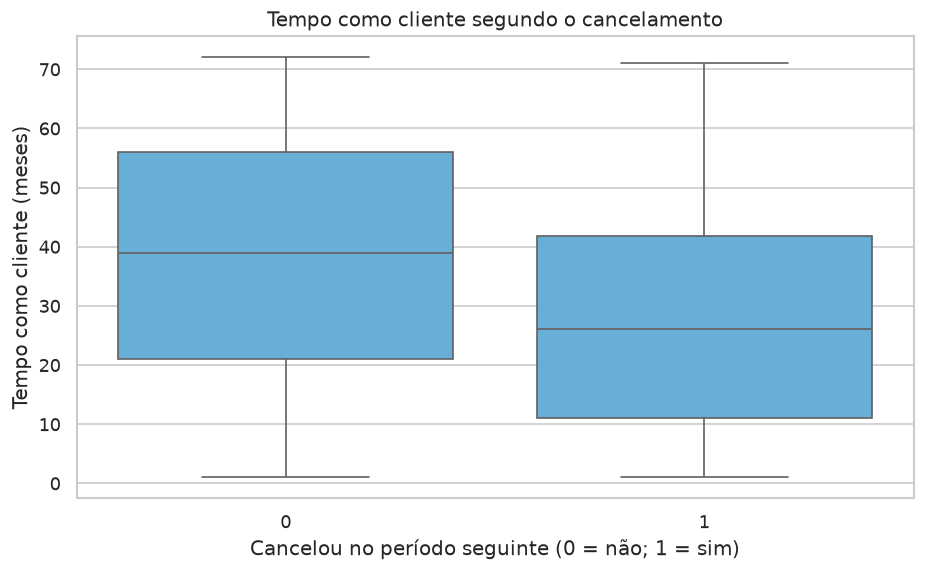

In [4]:
taxa_cancelamento = dados["cancelou"].mean()
print(f"Taxa de cancelamento: {taxa_cancelamento:.1%}")

sns.set_theme(style="whitegrid", context="notebook")
fig, ax = plt.subplots(figsize=(9, 5), dpi=120)
sns.boxplot(data=dados, x="cancelou", y="meses_como_cliente", color="#56B4E9", ax=ax)
ax.set(
    title="Tempo como cliente segundo o cancelamento",
    xlabel="Cancelou no período seguinte (0 = não; 1 = sim)",
    ylabel="Tempo como cliente (meses)",
)
plt.show()


A análise inicial verifica tipos e ausências e compara a distribuição de uma variável entre as classes. Diferenças entre grupos são pistas, não prova causal. Na Unidade V, construiremos modelos e avaliaremos seus erros em dados não usados no ajuste.

## Critério de sucesso

Acurácia isolada pode ser inadequada: se poucos clientes cancelam, prever “não cancela” para todos parece acertar muito, mas não encontra ninguém para contato. O critério deve refletir a decisão, por exemplo:

- encontrar uma fração relevante dos cancelamentos;
- limitar contatos desnecessários à capacidade da equipe;
- estimar benefício líquido considerando custo e efeito da intervenção;
- comparar o modelo a uma estratégia simples de referência.


## Vazamento e implantação

Um atributo causa **vazamento de dados** quando disponibiliza ao treinamento informação que não existirá no momento real da previsão ou que revela indevidamente o alvo. Um campo `data_do_cancelamento`, por exemplo, tornaria o exercício artificialmente fácil.

Mesmo um modelo válido pode se degradar quando clientes, produtos ou políticas mudam. Implantar exige registrar a versão, monitorar dados e métricas, analisar impactos entre grupos e definir quando revisar ou interromper o sistema.

> **U01-NB02-V01 — Verifique seu entendimento:** por que avaliar o modelo nos mesmos exemplos usados para ajustá-lo produz uma estimativa otimista?

> **U01-NB02-E01 — Exercício integrador:** escolha um problema de educação, saúde pública, indústria ou comércio e produza uma página contendo: decisão apoiada; unidade de análise; tarefa; atributos disponíveis no momento da decisão; alvo, se houver; critério de sucesso; dois riscos; e entregas de cada etapa do KDD. Não é necessário treinar um modelo.


## Onde estão as etapas do KDD neste estudo de caso?

O estudo percorreu algumas etapas, planejou outras e deixou partes deliberadamente para unidades posteriores. A tabela evita confundir uma demonstração introdutória com um projeto completo.

| Etapa do KDD | O que apareceu no estudo | Situação neste notebook | O que faltaria em um projeto real |
|---|---|---|---|
| Compreensão do problema | Priorização de contatos de retenção; previsão de cancelamento no próximo mês | Realizada em nível introdutório | Definir responsável pela decisão, capacidade de contato, custos, restrições e efeitos desejados |
| Seleção e compreensão dos dados | Atributos de tempo como cliente, mensalidade, chamados, atrasos e cancelamento; inspeção de tipos, valores únicos e ausências | Ilustrada com dados sintéticos | Obter dados reais, documentar origem, período, população, significado, qualidade e representatividade |
| Limpeza e transformação | Valores foram gerados em formato tabular; mensalidade foi limitada a um intervalo plausível na simulação | Apenas ilustrada; não houve limpeza real | Tratar ausências, duplicidades, inconsistências, categorias, escala e separação temporal sem vazamento |
| Mineração de dados | A função logística foi usada somente para **gerar** o alvo sintético | Não realizada | Separar dados e ajustar classificadores apenas no conjunto de treino; comparar com uma referência |
| Avaliação e interpretação | Taxa da classe, boxplot exploratório, discussão de causalidade, acurácia e custos dos erros | Parcial; não existe modelo avaliado | Escolher métricas, validar em dados não usados no ajuste, analisar erros, estabilidade, grupos e utilidade operacional |
| Conhecimento e comunicação | Foram discutidos priorização, vazamento, monitoramento e limites do resultado | Planejada, não implantada | Comunicar conclusões e incertezas, testar a intervenção, registrar decisões e monitorar efeitos após implantação |

> **Ponto importante:** calcular `probabilidade` no código não significa que treinamos um modelo. A fórmula foi definida por nós para simular os dados. Aprender uma relação a partir de exemplos, comparar modelos e avaliar generalização será parte da Unidade V.

### O caráter iterativo no caso

Se a avaliação futura mostrar que o modelo encontra cancelamentos, mas gera contatos demais, será necessário rever o critério de sucesso, o limiar ou a própria decisão. Se o desempenho cair para clientes novos, será preciso revisar população, período, atributos e preparação. Assim, uma descoberta em uma etapa pode levar de volta a qualquer etapa anterior.


## Síntese

- KDD é um processo completo e iterativo; mineração de dados é uma de suas etapas.
- Uma pergunta operacional clara orienta seleção, preparação, método e avaliação.
- Métricas devem representar o uso pretendido e os custos dos erros.
- Vazamento, mudança ao longo do tempo e impacto social podem invalidar um resultado aparentemente bom.

## Referências

- HAN, Jiawei; PEI, Jian; TONG, Hanghang. *Data Mining: Concepts and Techniques*. 4. ed. Cambridge: Morgan Kaufmann/Elsevier, 2023. Cap. 1, seções 1.1–1.7.
- FAYYAD, Usama; PIATETSKY-SHAPIRO, Gregory; SMYTH, Padhraic. From data mining to knowledge discovery in databases. *AI Magazine*, v. 17, n. 3, p. 37–54, 1996.
